# 修了課題DEMO④　CIFAR10



[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）

In [3]:
%%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.7.1

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.7.0.72

!pip uninstall torch -y
!pip install torch==2.0.1

!pip uninstall torchvision -y
!pip install torchvision==0.15.2

##はじめに
この修了課題では、Pytorchを使って「CIFAR10」という画像データセットの分類を行っていきます。  
今回使用するネットワーク構成は
    
    conv2d - relu - MaxPool2d -
    conv2d - relu - MaxPool2d -
    flatten -
    Linear - relu -
    Linear - relu - Linear
上記のようなCNNとなっています。  
ここで、viewとはサイズを１度調整するコマンドのことで、各要素の値そのものに変化はありません。  
また、Linearは線形結合を表しています。


##作成までの流れ
大まかな流れとして
1. データのダウンロードと正規化  
   torchvisionというライブラリを使用して、CIFAR10の訓練用のデータ、テスト用のデータをダウンロードします。  
   また、ダウンロードした画像に対して正規化を行います。

2. モデルの構築  
   学習を行うモデルの各層の役割を理解して、構築します。

3. 損失関数などの設定  
   学習を行うのに必要な損失関数などの設定を行います。

4. 学習と結果  
   訓練データで学習を行い、どのくらいの精度があるのかを、テスト用データを使って確認します。

##必要なライブラリーのインポートとGoogleDriveへの接続

In [1]:
#GoogleDriveへの接続を行う
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#必要なライブラリーのインポート
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#ダウンロードに必要なライブラリーのインポート
import pickle
from PIL import Image
import os

#1.データのダウンロードと正規化

## データのダウンロード

今回使用するデータを「wget」コマンドでダウンロードします。  
ダウンロードしたデータを直列に配置し、画像に変換する処理を行っていますが、  
今回はモデルの作成と学習が目的ですので、気にせず実行してください。

In [3]:
!wget 'https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3' -O train.pickle

--2026-01-19 03:13:23--  https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3
Resolving drive.google.com (drive.google.com)... 74.125.130.101, 74.125.130.102, 74.125.130.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.130.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download [following]
--2026-01-19 03:13:23--  https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31319904 (30M) [application/octet-stream]
Saving to: ‘train.pickle’

train.pickle        100%[===================>]  29.87M  52.3MB/s    

In [4]:
!wget 'https://drive.google.com/uc?export=download&id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN' -O val.pickle

--2026-01-19 03:13:26--  https://drive.google.com/uc?export=download&id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN
Resolving drive.google.com (drive.google.com)... 74.125.130.101, 74.125.130.102, 74.125.130.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.130.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN&export=download [following]
--2026-01-19 03:13:27--  https://drive.usercontent.google.com/download?id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6264552 (6.0M) [application/octet-stream]
Saving to: ‘val.pickle’

val.pickle          100%[===================>]   5.97M  20.7MB/s    in

下のセルで画像ファイルとして保存する処理を行っています。  
実行に平均1分程度かかりますが、データのダウンロードが完了します。

In [5]:
# バイナリファイルを読み込んでから、画像データに変換処理を行う。
def parse_pickle(rawdata, dataset_name):
    for i in range(10):
        dir = dataset_name + "/" + f"{i:02d}"
        if not os.path.exists(dir):
            os.makedirs(dir)
    m = len(rawdata["data"])
    for i in range(m):
        filename = f'{i}.png'
        label = rawdata["label"][i]
        data = rawdata["data"][i]
        data = data.reshape(3, 32, 32)
        data = np.swapaxes(data, 0, 2)
        data = np.swapaxes(data, 0, 1)
        with Image.fromarray(data) as img:
            img.save(f"{dataset_name}/{label:02d}/{filename}")

train = {'label':[], 'data':[]}
with open('train.pickle', "rb") as fp:
  train = pickle.load(fp, encoding="latin-1")
parse_pickle(train, "train")

with open('val.pickle', "rb") as fp:
  val = pickle.load(fp, encoding="latin-1")
parse_pickle(val, "val")

##データ拡張とデータセット作成
画像認識において「データ拡張」は汎化性能を上げる重要な役割を果たします。  
torchvision.transforms という PyTorch のサブライブラリを用いてデータ拡張を行います。  
また、transforms.Composeの中に記入することで、記入したtransformのコマンドを一度に実行することができます。

今回は一般的に必要な  

*  画像のテンソル化 ( transforms.ToTensor() )  
*  RGBの平均と標準偏差をそれぞれ0.5に設定する正規化 ( transforms.Nomalize())

を行いました。

Pytorchが提供しているその他のtransformのURLを記載しておくので、精度が上がる手法をそれぞれ試してみてください。  
データ拡張:https://pytorch.org/vision/stable/transforms.html

In [6]:
# データ拡張の設定
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                #もっと増やしてみてもいいかもしれません
                                ])

次にバッチサイズとデータをまとめる処理になります。

In [7]:
# バッチサイズの設定
batch_size = 4

# データローダーの設定
trainset = torchvision.datasets.ImageFolder(root='train', transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

valset = torchvision.datasets.ImageFolder(root='val', transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

データの量を確認します。

In [8]:
print('学習データ:', len(trainset))
print('検証データ:', len(valset))

学習データ: 10000
検証データ: 2000


##データの確認
ここで一度、データがどのようなものなのか確認してみましょう。

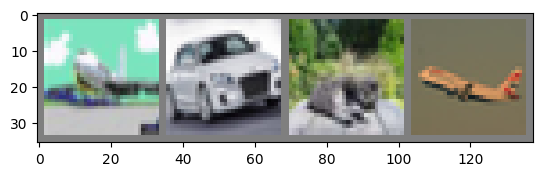

plane car   cat   plane


In [9]:
# 画像を格子状に表示する関数
def imshow(img):
    img = img / 2 + 0.5     #非正規化する
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


#画像をいくつか取得
dataiter = iter(trainloader)
images, labels = next(dataiter)

#画像を表示する
imshow(torchvision.utils.make_grid(images))
#画像の下にそれぞれのラベルを表示
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 2.モデルの構築
先ほど紹介したCNNを作成してみましょう。

今回のネットワーク構成：

    conv2d - relu - MaxPool2d -
    conv2d - relu - MaxPool2d -
    flatten -
    Linear - relu -
    Linear - relu - Linear

In [10]:
# シンプルなCNNモデルの構築
class Net(nn.Module):
    def __init__(self):
      #まずここで各層がどのようなものか定義をしておく
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
      #initで定義されたものを実際に配置する
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

#3.損失関数などの設定
損失関数(criterion)と最適化手法(optimizer)について設定します。  
Pytorchが提供しているcriterionとoptimizerのURLを記載しておくので、精度が上がる手法をそれぞれ試してみてください。  


*   criterion:https://pytorch.org/docs/stable/nn.html#loss-functions
*   optimizer:https://pytorch.org/docs/stable/optim.html


In [11]:
# 損失関数の設定
criterion = nn.CrossEntropyLoss()
# 最適化関数の設定
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

#4.学習と結果

学習を実際に行ってみましょう。  
様子を確認するためにLossの平均を2000ミニバッチごとに表示してみます。

In [12]:
# 学習エポックの設定
epoch_num = 5

# 学習ループの設定
for epoch in range(epoch_num):
    # 誤差の初期化
    running_loss = 0.0

    # データの取り出し
    for i, data in enumerate(trainloader, 0):
        # 画像データとラベルの取り出し
        inputs, labels = data
        # 勾配の初期化
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #途中結果を表示する
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.238
[2,  2000] loss: 1.822
[3,  2000] loss: 1.603
[4,  2000] loss: 1.490
[5,  2000] loss: 1.367
Finished Training


##結果のモデルを保存する


In [13]:
cnn_weight_path = './cnn_weight.pth'
torch.save(net.state_dict(), cnn_weight_path)

##結果を検証用データで確認する

In [14]:
net.load_state_dict(torch.load(cnn_weight_path))

<All keys matched successfully>

In [15]:
correct = 0
total = 0
# 勾配を記憶せず（学習せずに）に計算を行う
with torch.no_grad():
    for data in valloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('正解率 : %d %%' % (100 * correct / total))

正解率 : 43 %


正解率が表示されたと思います。  
なお、このモデルはモデル容量が小さく、学習回数を重ねても早い段階で精度向上の限界が訪れます。(学習回数を100エポックにするなどをしてみて下さい。)  
このままでは実用に値する精度とは言えないので、モデル容量が大きい発展的なモデルを適用する必要があります。

# 5.発展的なモデルを用いて学習する

今回は発展的なモデルとして「VGG11」を試してみます。

また、ほかのモデルのコードなどを参照したい場合は  
https://github.com/kuangliu/pytorch-cifar  
を見てみましょう。

その他にResNet などもありますので、試してみて下さい。  
ResNetがどういうものなのかは以下のURLで詳しく述べているので、是非読んでみてください。

代表的モデル「ResNet」、「DenseNet」を詳細解説！：https://deepsquare.jp/2020/04/resnet-densenet/



In [16]:
cfg = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
}

# VGG モデルの設定
class VGG(nn.Module):
    def __init__(self, vgg_name):
        super(VGG, self).__init__()
        self.features = self._make_layers(cfg[vgg_name])
        # Cifar10 用に10種類分類にする
        self.classifier = nn.Linear(512, 10)

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        layers += [nn.AvgPool2d(kernel_size=1, stride=1)]
        return nn.Sequential(*layers)

In [17]:
# モデルのインスタンスを作成
net = VGG('VGG11')

# 損失関数の設定
criterion = nn.CrossEntropyLoss()
# 最適化関数の設定
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [18]:
# 学習エポックの設定
epoch_num = 5

# 学習ループの設定
for epoch in range(epoch_num):
    # 誤差の初期化
    running_loss = 0.0

    # データの取り出し
    for i, data in enumerate(trainloader, 0):
        # 画像データとラベルの取り出し
        inputs, labels = data
        # 勾配の初期化
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #途中結果を表示する
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

[1,  2000] loss: 2.034
[2,  2000] loss: 1.507
[3,  2000] loss: 1.238
[4,  2000] loss: 1.021
[5,  2000] loss: 0.823


##結果のモデルを保存する

In [19]:
vgg_weight_path = './vgg_weight.pth'
torch.save(net.state_dict(), vgg_weight_path)

##結果を検証用データで確認する

In [20]:
net.load_state_dict(torch.load(vgg_weight_path))

<All keys matched successfully>

In [21]:
correct = 0
total = 0
# 勾配を記憶せず（学習せずに）に計算を行う
with torch.no_grad():
    for data in valloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('正解率 : %d %%' % (100 * correct / total))

正解率 : 41 %


先程作成したシンプルなCNNモデルよりも精度が悪化しますが、  
これはモデルの容量が大きくなったため学習量が足りていないことが原因です。  
転移学習を利用して、より学習させたモデルを利用することでVGGモデルの性能の本来の力を確認しましょう。

# 6.転移学習

5章で作成したVGG11は、重みを１から作成して学習を始めました。  
発展的なモデルはモデルの容量が大きくなった分、１回の学習時間が非常に長くなってしまうという問題点があります。  
そのため、長期間学習を行わないと適した精度まで上がらないため、あまり実用的ではありません。  
そこで、事前にある程度学習が行われている事前学習済みモデルを利用する「転移学習」という手法を用います。

PyTorchの公式サイトに掲載されているように、転移学習を実装したモデルを使ってみましょう。

PyTorchの公式サイト：https://pytorch.org/vision/stable/models.html

In [22]:
# pytorch のライブラリーを利用して、事前学習の重みをロード済みのモデルインスタンスを作成する。
# なお、pretrained=True とすると事前学習モデルとなり、Falseとするとモデルのみが作成される。
net = torchvision.models.vgg11(pretrained=True)
net

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:02<00:00, 188MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [23]:
# 分類器部分を cifar10 用に付け替える。
net.classifier[6] = nn.Linear(4096,out_features=10)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
net = net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [26]:
# 学習エポックの設定
epoch_num = 5

# 学習ループの設定
for epoch in range(epoch_num):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()

        # テンソルをGPUに移動
        inputs = inputs.to(device)
        labels = labels.to(device)

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 結果表示
        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0
print('Finished Training')

[1,  2000] loss: 1.382
[2,  2000] loss: 0.772
[3,  2000] loss: 0.530
[4,  2000] loss: 0.391
[5,  2000] loss: 0.256
Finished Training


##結果のモデルを保存する


In [27]:
vgg_pre_weight_path = './vgg_pre_weight_path.pth'
torch.save(net.state_dict(), vgg_pre_weight_path)

##結果を検証用データで確認する

In [28]:
net.load_state_dict(torch.load(vgg_pre_weight_path))

<All keys matched successfully>

In [29]:
correct = 0
total = 0
# 勾配を記憶せず（学習せずに）に計算を行う
with torch.no_grad():
    for data in valloader:
        images, labels = data

        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('正解率 : %d %%' % (100 * correct / total))

正解率 : 76 %


## （参考）提出用データの作成の仕方

上記のモデルでテスト用データを予測して提出用ファイルを出力するまでを
掲載してみました。

実行してみましょう。

In [30]:
!wget 'https://drive.google.com/uc?export=download&id=1-T-luRcFf14qV_rR66B3groh8imA-8lo' -O test_data.pickle

--2026-01-19 03:56:52--  https://drive.google.com/uc?export=download&id=1-T-luRcFf14qV_rR66B3groh8imA-8lo
Resolving drive.google.com (drive.google.com)... 172.253.118.102, 172.253.118.139, 172.253.118.138, ...
Connecting to drive.google.com (drive.google.com)|172.253.118.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-T-luRcFf14qV_rR66B3groh8imA-8lo&export=download [following]
--2026-01-19 03:56:52--  https://drive.usercontent.google.com/download?id=1-T-luRcFf14qV_rR66B3groh8imA-8lo&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6259881 (6.0M) [application/octet-stream]
Saving to: ‘test_data.pickle’

test_data.pickle    100%[===================>]   5.97M  25.5

In [31]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

with open('test_data.pickle', "rb") as fp:
  test = pickle.load(fp, encoding="latin-1")

for i in range(len(test['data'])):
  data = test["data"][i]
  data = data.reshape(3, 32, 32)
  data = np.swapaxes(data, 0, 2)
  data = np.swapaxes(data, 0, 1)
  img = transform(data)
  img = torch.unsqueeze(img, 0)
  if i==0:
    images=img
  else:
    images = torch.cat([images, img])

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.eval()
images = images.to(device)
with torch.no_grad():
    outputs = net(images)
    _, predictions = torch.max(outputs, 1)
print(predictions)

tensor([8, 9, 9,  ..., 2, 0, 0], device='cuda:0')


In [33]:
# pandasのDataFrame形式に変換し、CSV出力する
import pandas as pd
y_pred = pd.DataFrame(predictions.cpu(), columns=['number'])
y_pred.to_csv('y_pred.csv')
y_pred

,number
0,8
1,9
2,9
3,4
4,2
...,...
1995,7
1996,0
1997,2
1998,0


In [34]:
!wget 'https://drive.google.com/uc?export=download&id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI' -O test_label.pickle
with open('test_label.pickle', "rb") as fp:
  test_label = pickle.load(fp, encoding="latin-1")

--2026-01-19 03:57:06--  https://drive.google.com/uc?export=download&id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI
Resolving drive.google.com (drive.google.com)... 172.253.118.102, 172.253.118.139, 172.253.118.138, ...
Connecting to drive.google.com (drive.google.com)|172.253.118.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI&export=download [following]
--2026-01-19 03:57:07--  https://drive.usercontent.google.com/download?id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4023 (3.9K) [application/octet-stream]
Saving to: ‘test_label.pickle’

test_label.pickle   100%[===================>]   3.93K  --.-KB

In [35]:
labels = torch.tensor(test_label['label'])
correct = (predictions.cpu() == labels).sum().item()
assert len(predictions) == len(labels)
print( f"正解率 : {100 * correct // len(labels)} %" )

正解率 : 74 %
